In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'D:\vs code projects\swiggy_delivery_time\data\raw\final_data.csv')

In [4]:
df.isna().sum()

rider_id                   0
age                     2345
ratings                 2415
restaurant_latitude     4499
restaurant_longitude    4499
delivery_latitude       4499
delivery_longitude      4499
order_date                 0
weather                  664
traffic                  645
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries     1231
festival                 293
city_type               1522
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     2065
order_time_hour         2065
order_time_of_day          0
distance                4499
dtype: int64

In [8]:
missing_rows = (
    df
    .isna()
    .any(axis=1)
    .sum()
)

print(f'There are {missing_rows} rows with missing values in the data.')

print(f"It accounts for {(missing_rows/df.shape[0])*100:.2f}% of the data")

There are 9298 rows with missing values in the data.
It accounts for 16.35% of the data


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

rider_id                    str
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date                  str
weather                     str
traffic                     str
vehicle_condition         int64
type_of_order               str
type_of_vehicle             str
multiple_deliveries     float64
festival                    str
city_type                   str
time_taken                int64
city_name                   str
order_day                 int64
order_month               int64
order_day_of_week           str
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day           str
distance                float64
dtype: object

In [11]:
num_cols = df.columns[[1,2,3,4,5,6,16,22,25]].tolist()
cat_cols = [col for col in df.columns.tolist() if col not in num_cols]

print(f'There are {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns in the data.')

There are 9 numerical columns and 17 categorical columns in the data.


In [13]:
num_cols,cat_cols

(['age',
  'ratings',
  'restaurant_latitude',
  'restaurant_longitude',
  'delivery_latitude',
  'delivery_longitude',
  'time_taken',
  'pickup_time_minutes',
  'distance'],
 ['rider_id',
  'order_date',
  'weather',
  'traffic',
  'vehicle_condition',
  'type_of_order',
  'type_of_vehicle',
  'multiple_deliveries',
  'festival',
  'city_type',
  'city_name',
  'order_day',
  'order_month',
  'order_day_of_week',
  'is_weekend',
  'order_time_hour',
  'order_time_of_day'])

In [14]:
df[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutes,distance
count,54537.000000,54467.000000,52383.000000,52383.000000,52383.000000,52383.000000,56882.000000,54817.000000,52383.000000
mean,29.546106,4.635137,18.921819,76.919126,18.985529,76.982836,26.293133,9.998632,9.726945
std,5.759906,0.316189,5.469953,3.498463,5.471616,3.498724,9.388288,4.086447,5.603701
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,5.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.066286,73.940547,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662278,26.000000,10.000000,9.193021
75%,35.000000,4.900000,22.751234,78.368855,22.821226,78.405467,32.000000,15.000000,13.680927
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [15]:
(
    df
    .assign(**{
        col: df[col].astype("object")
        for col in cat_cols
    })
    .describe(include="object")
    .T
)

,count,unique,top,freq
rider_id,56882,1320,INDORES13DEL02,72
order_date,56882,44,2022-04-05,1440
weather,56218,6,fog,9422
traffic,56237,4,low,19358
vehicle_condition,56882,4,2,18855
type_of_order,56882,4,snack,14322
type_of_vehicle,56882,4,motorcycle,33032
multiple_deliveries,55651.0,4.0,1.0,35162.0
festival,56589,2,no,55492
city_type,55360,3,metropolitian,42510


Missing Value Analysis



In [16]:
import missingno as msno

<Axes: >

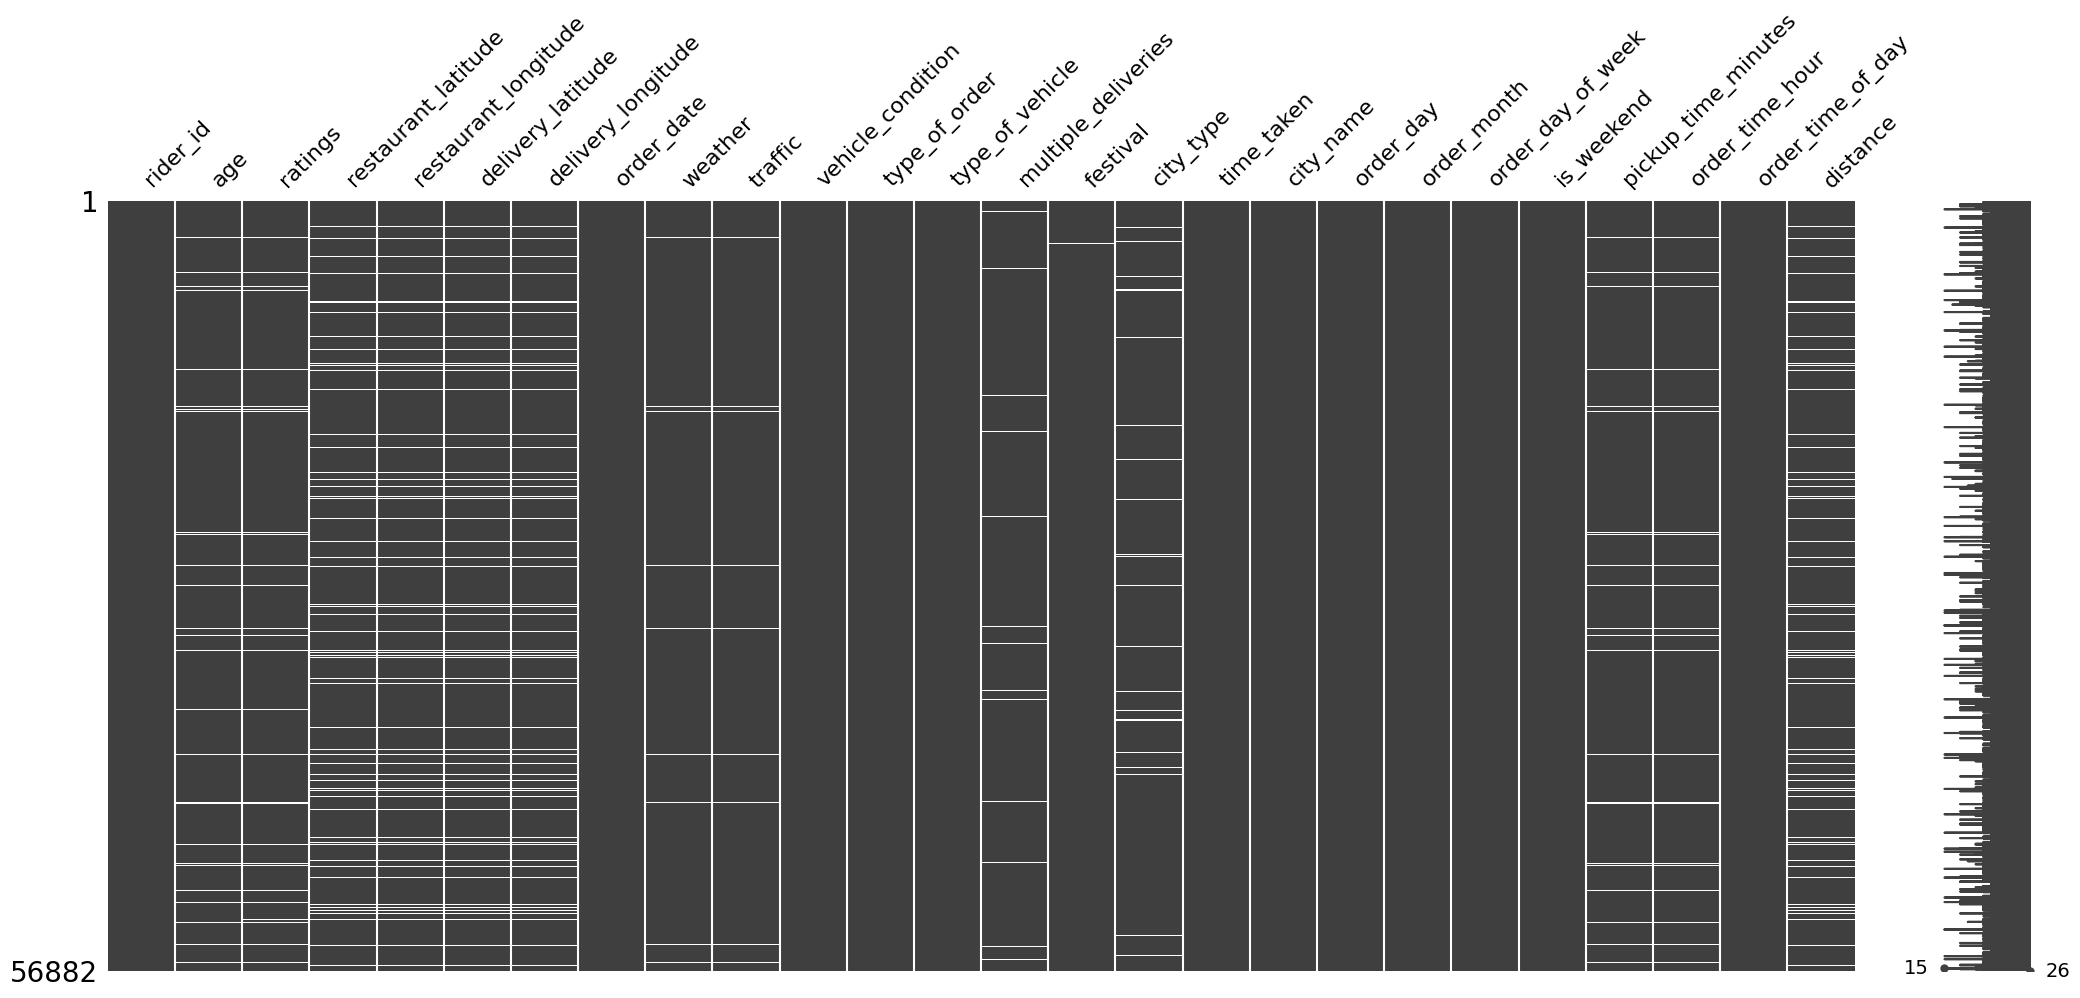

In [17]:
msno.matrix(df)

<Axes: >

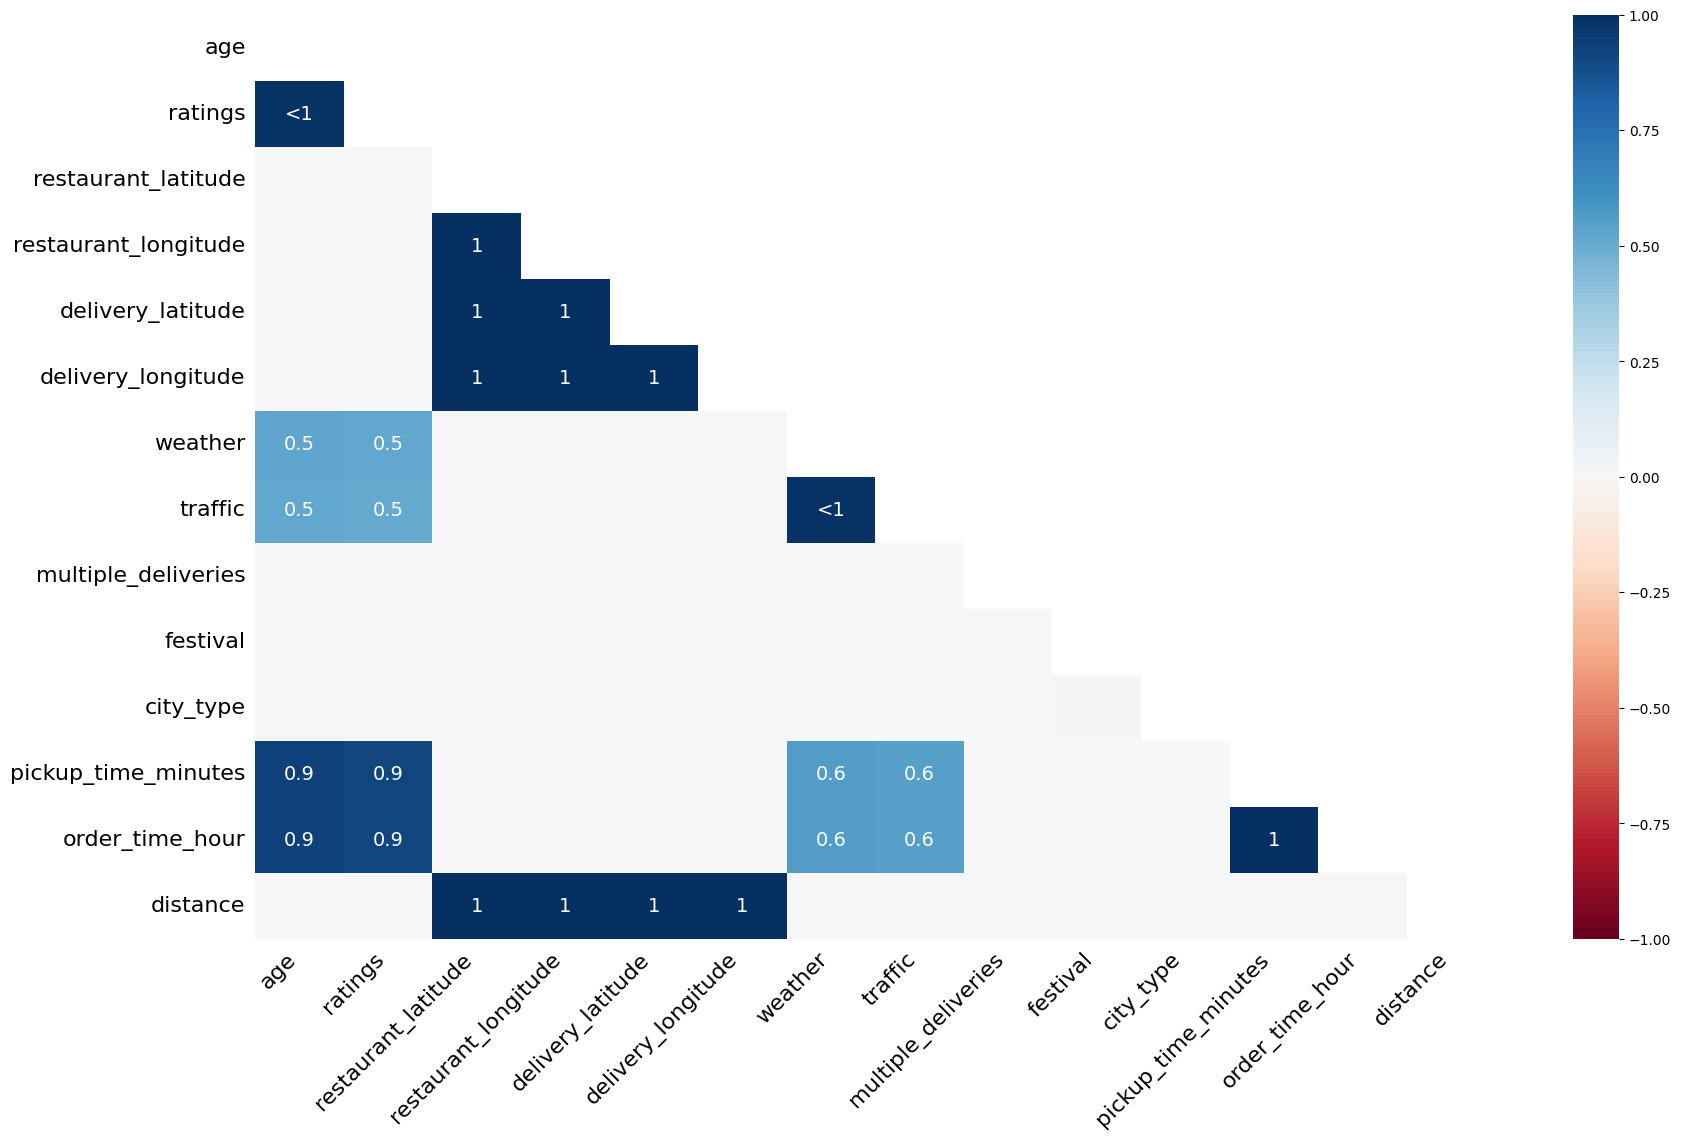

In [18]:
msno.heatmap(df)

<Axes: >

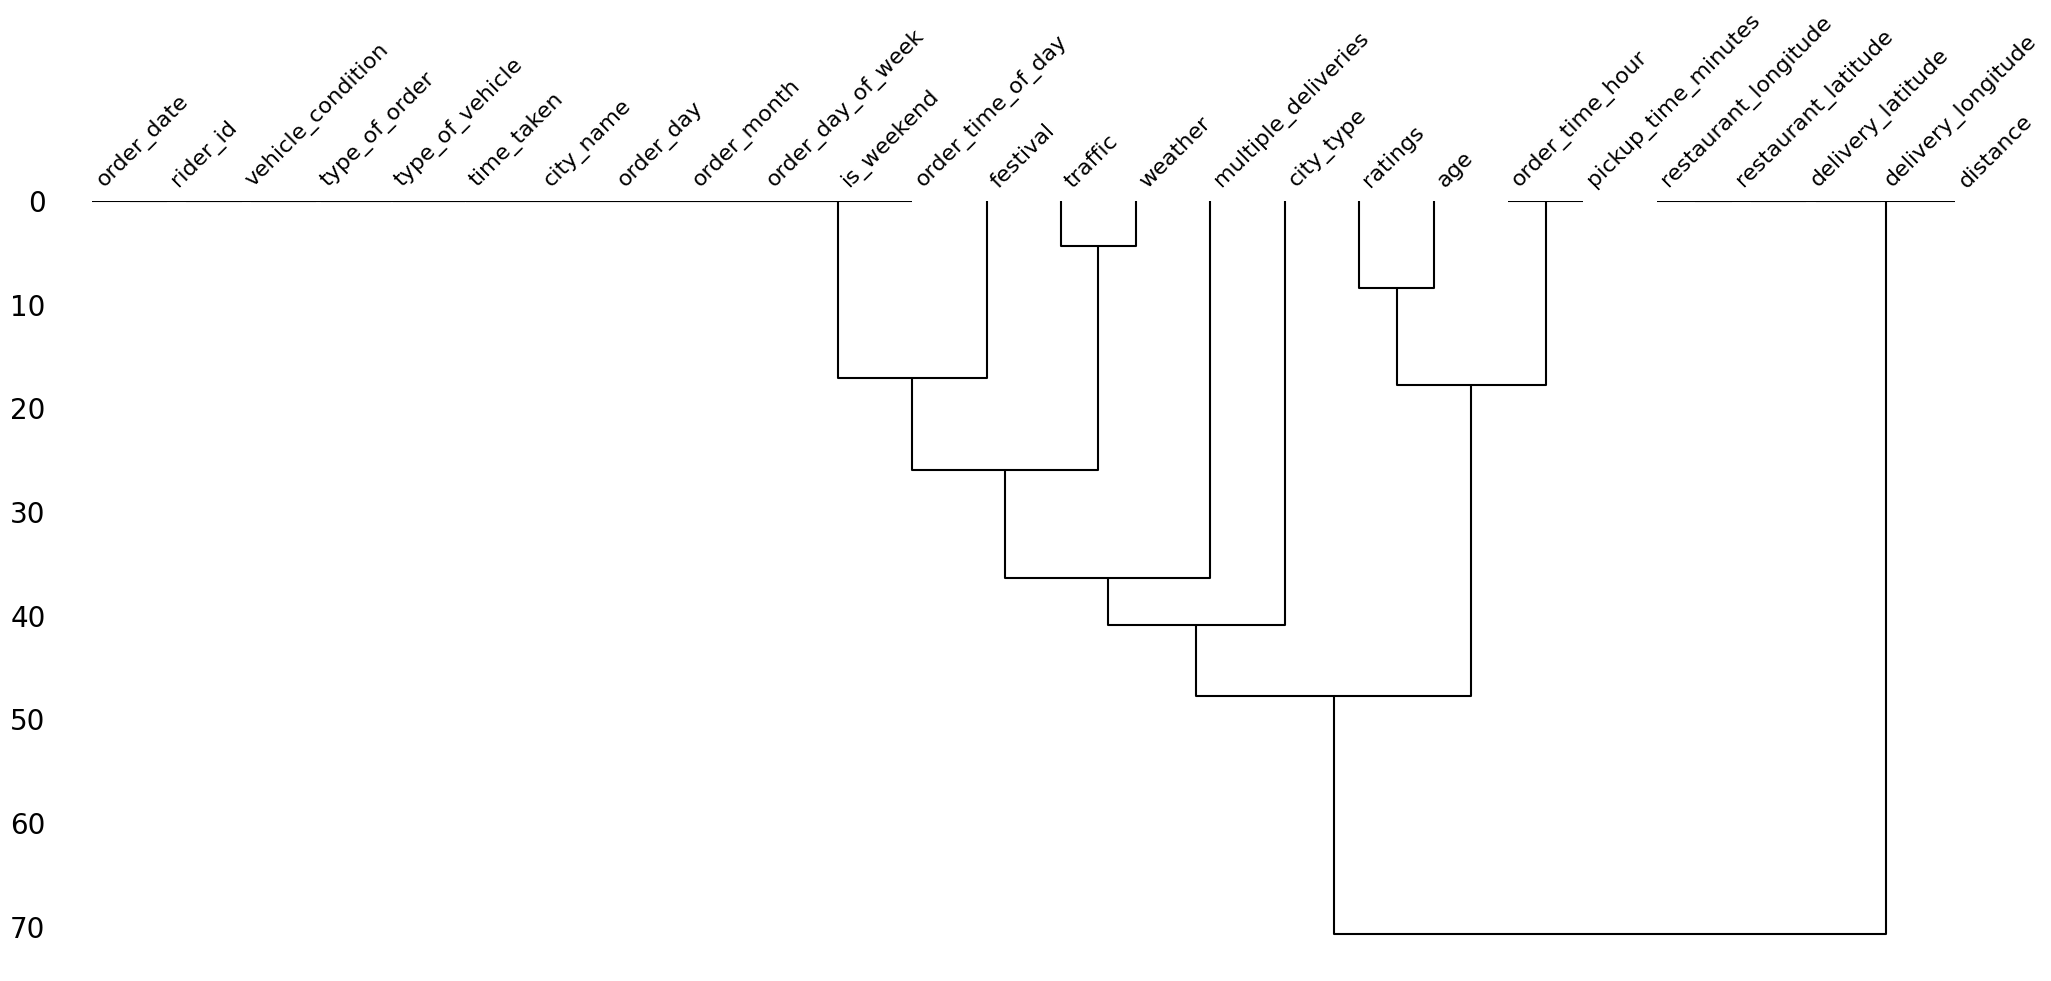

In [19]:
msno.dendrogram(df)

## Functions to perform analysis

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import plotly.express as px

In [21]:
def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15,10))
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name,hue=cat_col, ax=ax1)
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name,hue=cat_col, ax=ax2)
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name,bins=bins,hue=cat_col,kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])
    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        })
    )
    print("*" * 50)
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1,
                  y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()

def chi_2_test(dataframe, col1, col2, alpha= 0.05):
    data = (
        dataframe.loc[:, [col1, col2]]
        .dropna()
    )
    # create contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # perform chi-squared test
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant association between {col1} and {col2}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant association between {col1} and {col2}.")

def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    data = (
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_group]
    f_stat, p_val = f_oneway(*groups)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant relationship between {num_col} and {cat_col}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant relationship between {num_col} and {cat_col}.")

def test_for_normality(dataframe, column_name, alpha=0.05):
    data = dataframe[column_name]
    print("Jarque Bera Test for Normality")
    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis. The data is normally distributed.",end="\n\n")


In [22]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='str')

### Time Taken (Target)

In [23]:
df['time_taken'].dtype

dtype('int64')

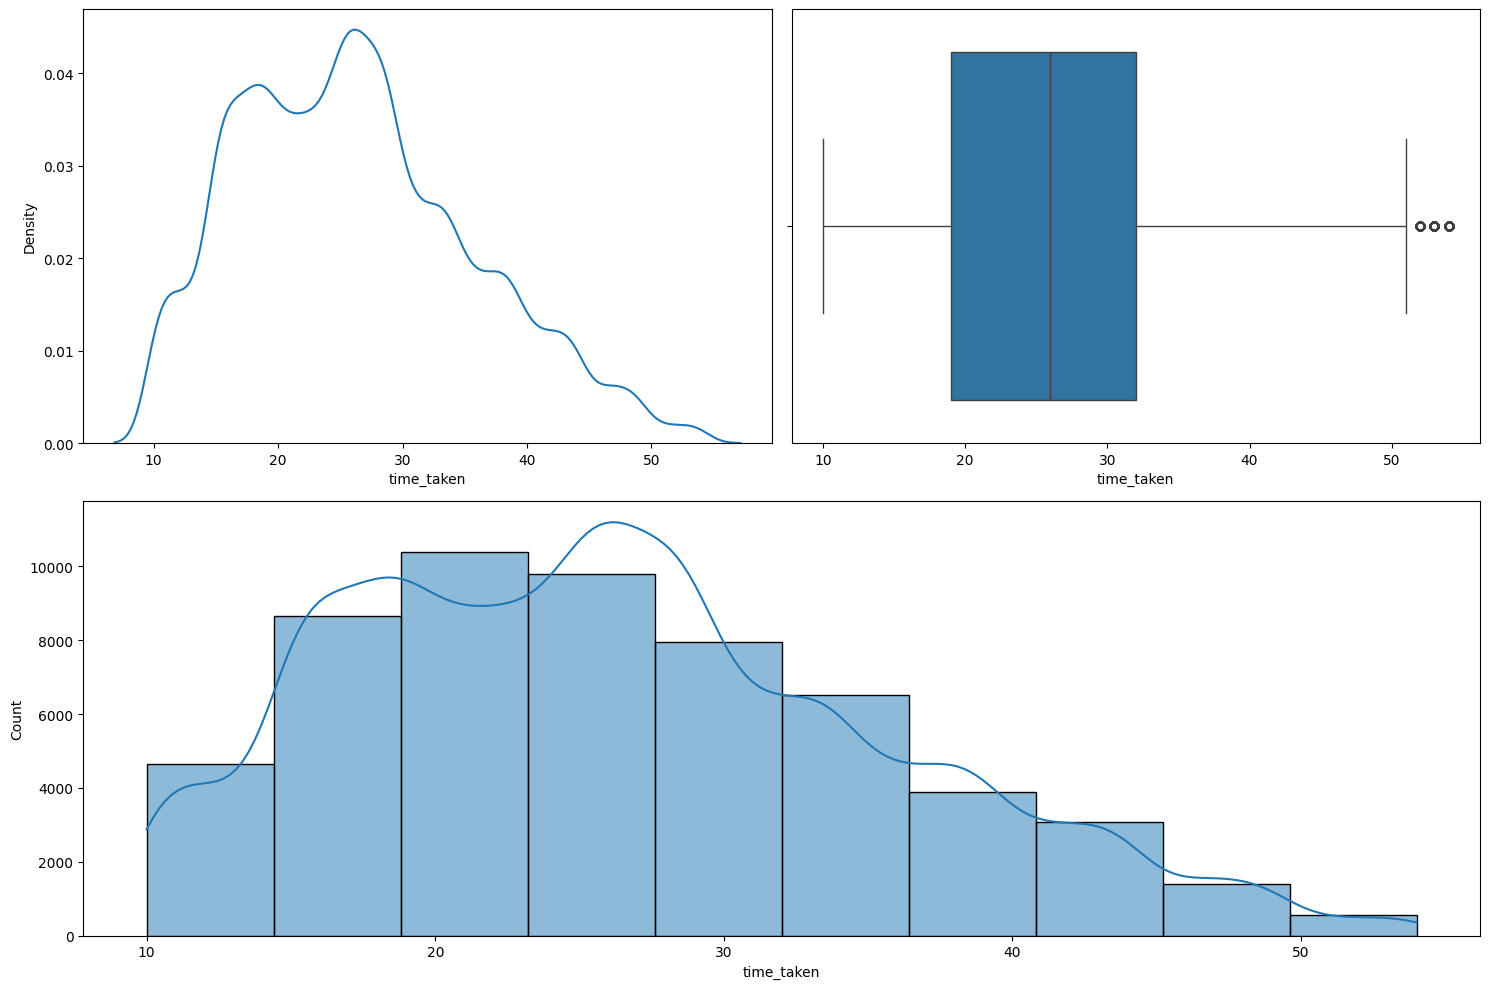

In [24]:
numerical_analysis(df, 'time_taken',bins=10)

Observations:

The target column is not fully continuous in nature.

The target column shows dual modality with two peaks- One peak around the 17-18 mark and other around 26-27 mark.

The target column has some extreme points which can be thought of as outliers but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

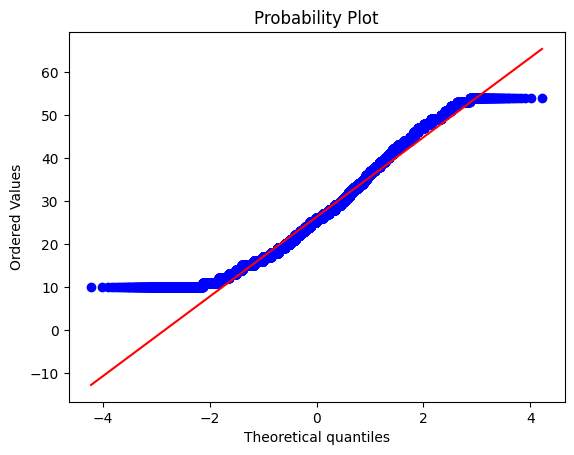

In [25]:
probplot(df['time_taken'], plot=plt)
plt.show()

In [26]:
test_for_normality(df, 'time_taken')

Jarque Bera Test for Normality
0.0
Reject the null hypothesis. The data is not normally distributed.


In [27]:
target_25_per, target_75_per = np.percentile(df['time_taken'], [25, 75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df.loc[(df['time_taken'] > upper_bound),"traffic"].value_counts()

traffic
jam       268
high       32
low        19
medium     17
Name: count, dtype: int64

In [28]:
df.loc[(df['time_taken'] > upper_bound),"weather"].value_counts()

weather
fog           70
sunny         59
cloudy        55
windy         53
stormy        52
sandstorms    47
Name: count, dtype: int64

In [29]:
avg_distance = df.loc[:,"distance"].mean()
avg_distance_extreme = df.loc[(df['time_taken'] > upper_bound),"distance"].mean()

print(avg_distance, avg_distance_extreme)

9.726944799793623 12.492627627972507


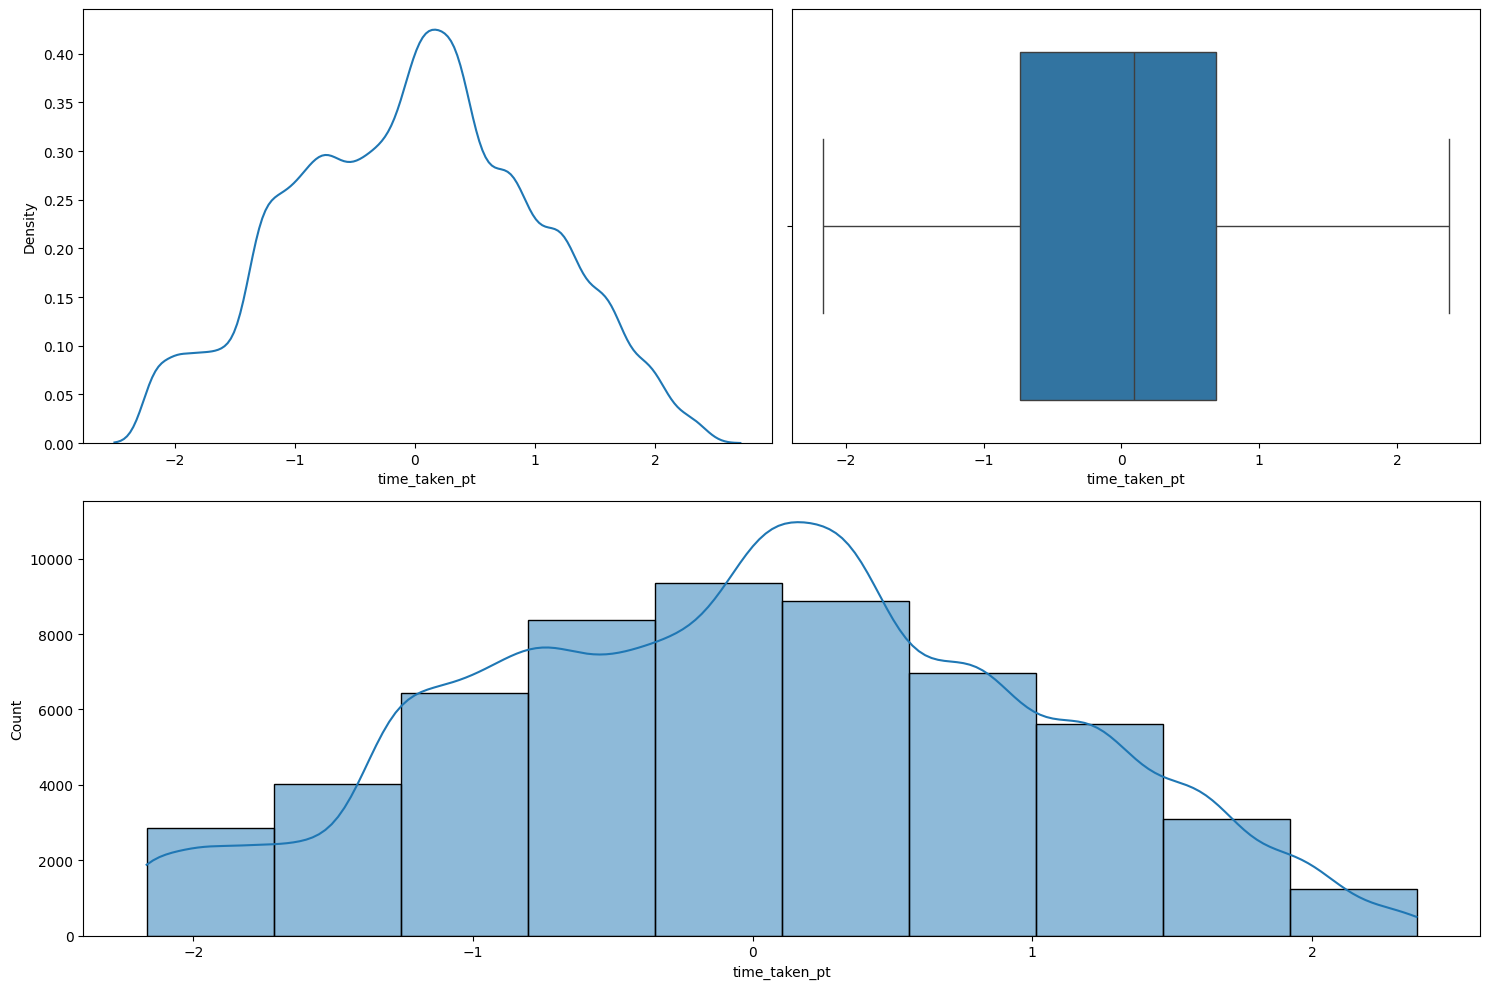

In [30]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df['time_taken_pt'] = pt.fit_transform(df[['time_taken']])

numerical_analysis(df, "time_taken_pt", bins=10)

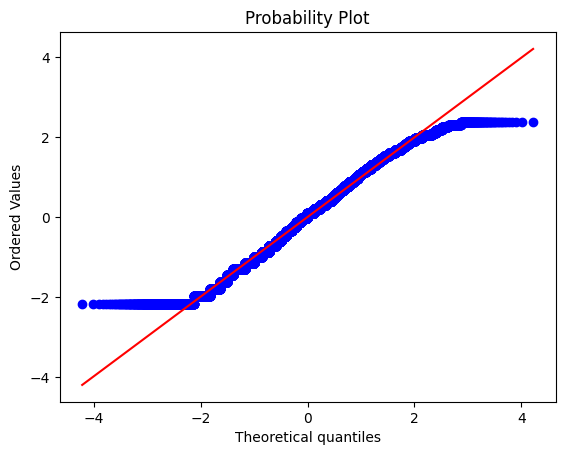

In [31]:
probplot(df['time_taken_pt'], plot=plt)
plt.show()

### Rider_id

In [32]:
df[["rider_id","age","ratings"]]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
56877,JAPRES01DEL01,35.0,4.6
56878,JAPRES11DEL01,33.0,4.9
56879,SURRES11DEL03,NaN,NaN
56880,VADRES03DEL02,27.0,4.7


In [33]:
rider_id_group = df[["rider_id","age","ratings"]].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
4554,AGRRES010DEL01,38.0,4.7
7738,AGRRES010DEL01,21.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
5094,VADRES20DEL03,35.0,4.9
5146,VADRES20DEL03,37.0,4.9
9753,VADRES20DEL03,38.0,4.8


In [34]:
df[["rider_id","age","ratings"]].dropna().duplicated(keep=False).sum()

np.int64(15298)

### Age

In [36]:
df['age'].dtype

dtype('float64')

In [37]:
df['age'].describe()

count    54537.000000
mean        29.546106
std          5.759906
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

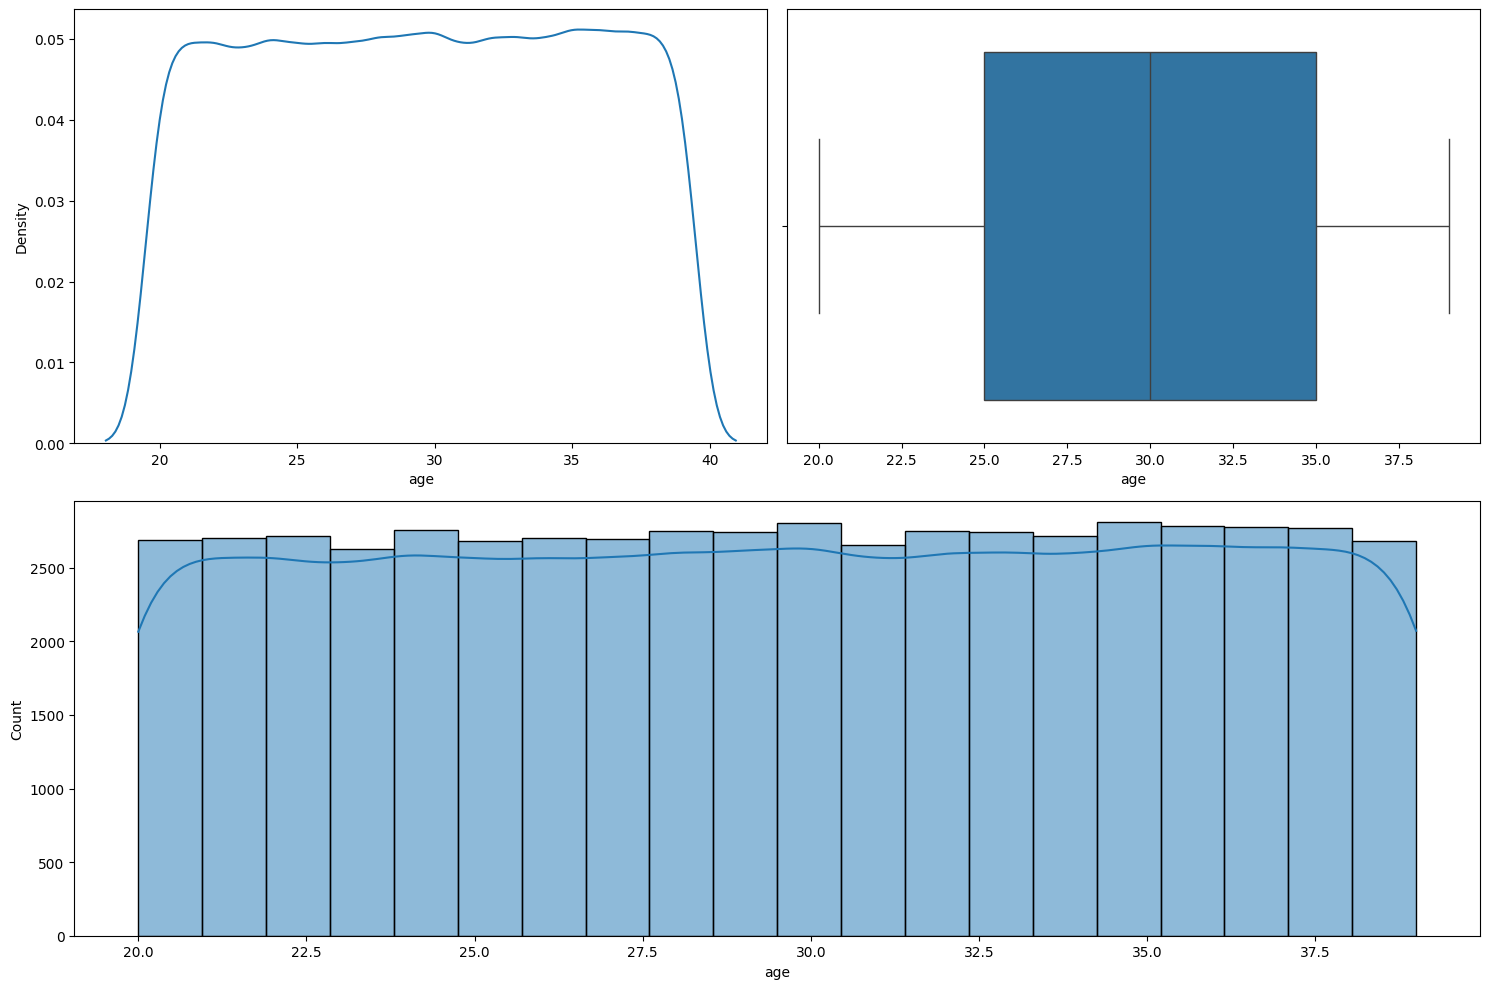

In [38]:
numerical_analysis(df, 'age',bins=20)

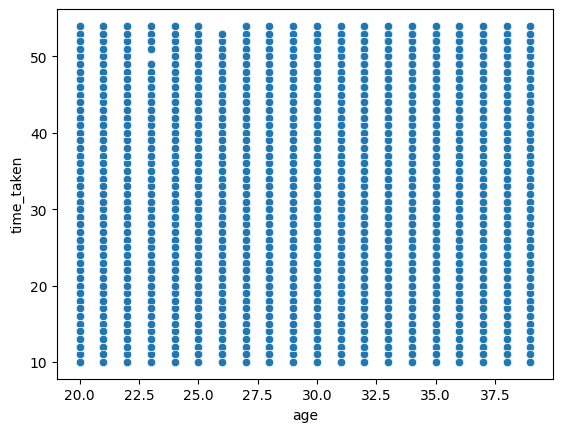

In [39]:
sns.scatterplot(data=df, x='age', y='time_taken')
plt.show()

Age of the rider does not show any impact on timetaken to deliver

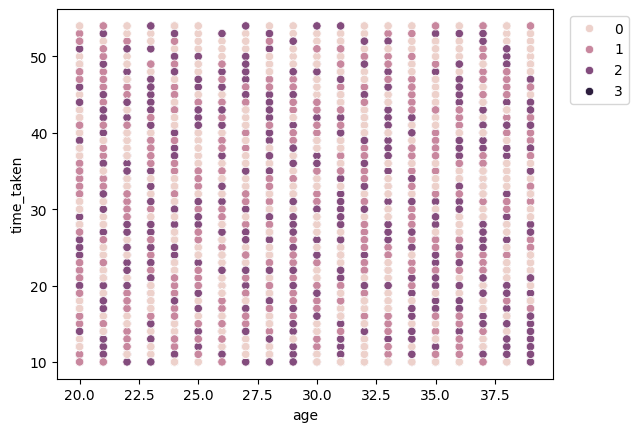

In [40]:
sns.scatterplot(data=df, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

<Axes: xlabel='type_of_vehicle', ylabel='age'>

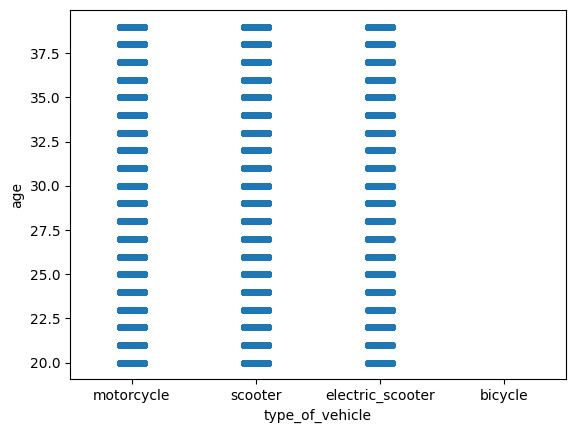

In [41]:
sns.stripplot(df,x='type_of_vehicle',y='age')

Ratings

In [42]:
df['ratings'].dtype

dtype('float64')

In [43]:
df['ratings'].describe()

count    54467.000000
mean         4.635137
std          0.316189
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

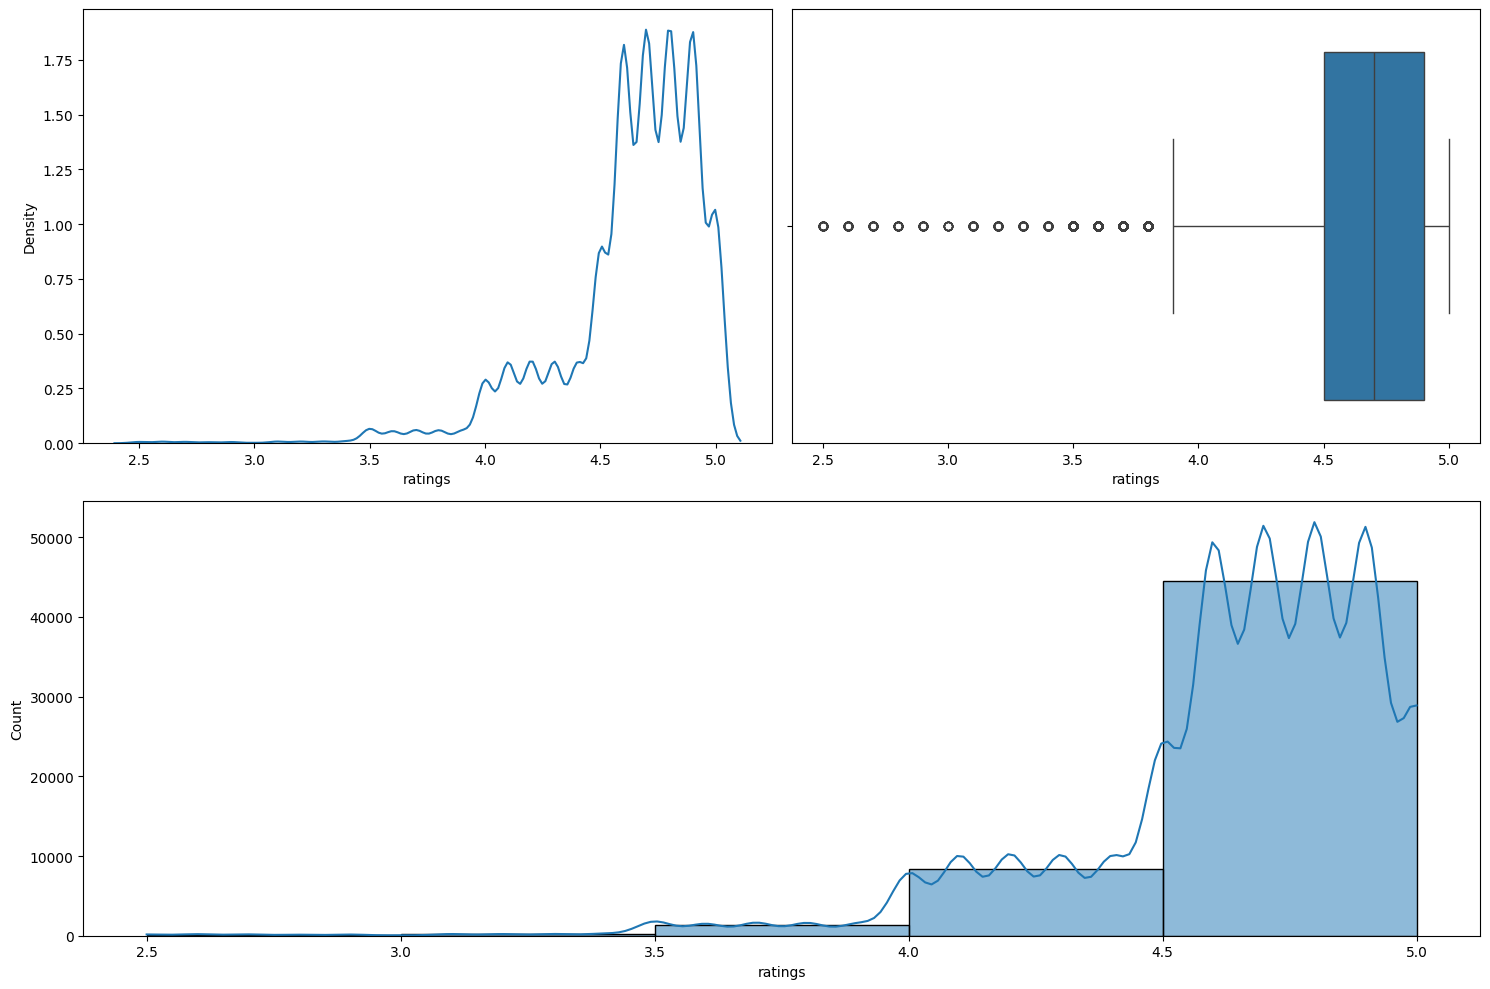

In [44]:
numerical_analysis(df, 'ratings',bins=5)

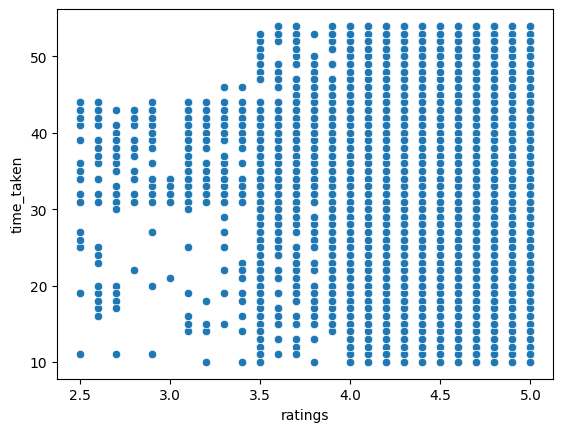

In [45]:
sns.scatterplot(data=df, x='ratings', y='time_taken')
plt.show()

It seems like riders with more ratings get more orders

Higher ratings equates to more work and more income opportunities

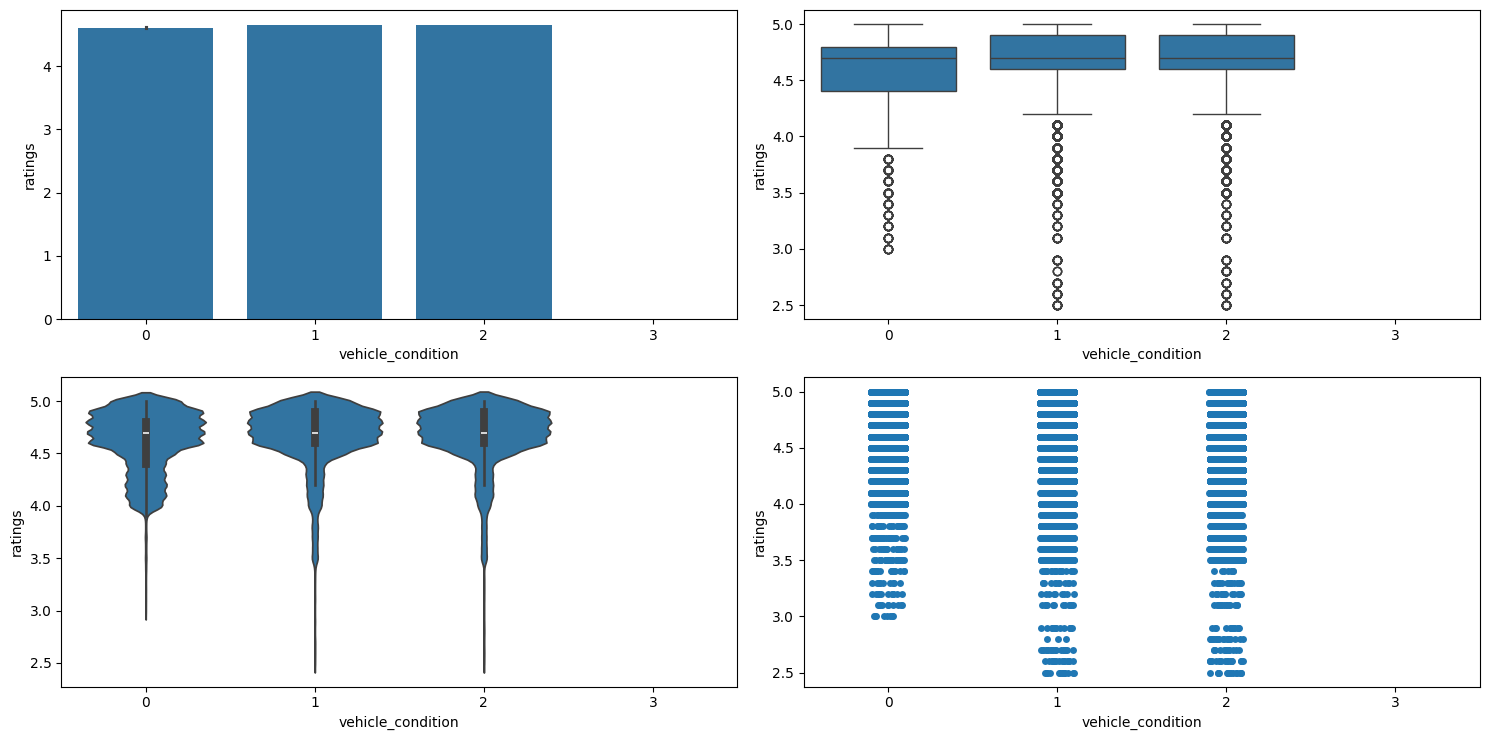

In [46]:
numerical_categorical_analysis(df, 'vehicle_condition', 'ratings')

Yes they do

The more worst the vehicle condition is, the more lower the rating gets.

The category 3 has no data means there are NaN values. This simply means that customers avoid rating their riders even rating of 1 when the vehicle condition is bad.

In [47]:
(
    df[["ratings","vehicle_condition"]]
    .loc[df["vehicle_condition"]==3,"ratings"]
    .value_counts(dropna=False)
)

ratings
NaN    537
Name: count, dtype: int64

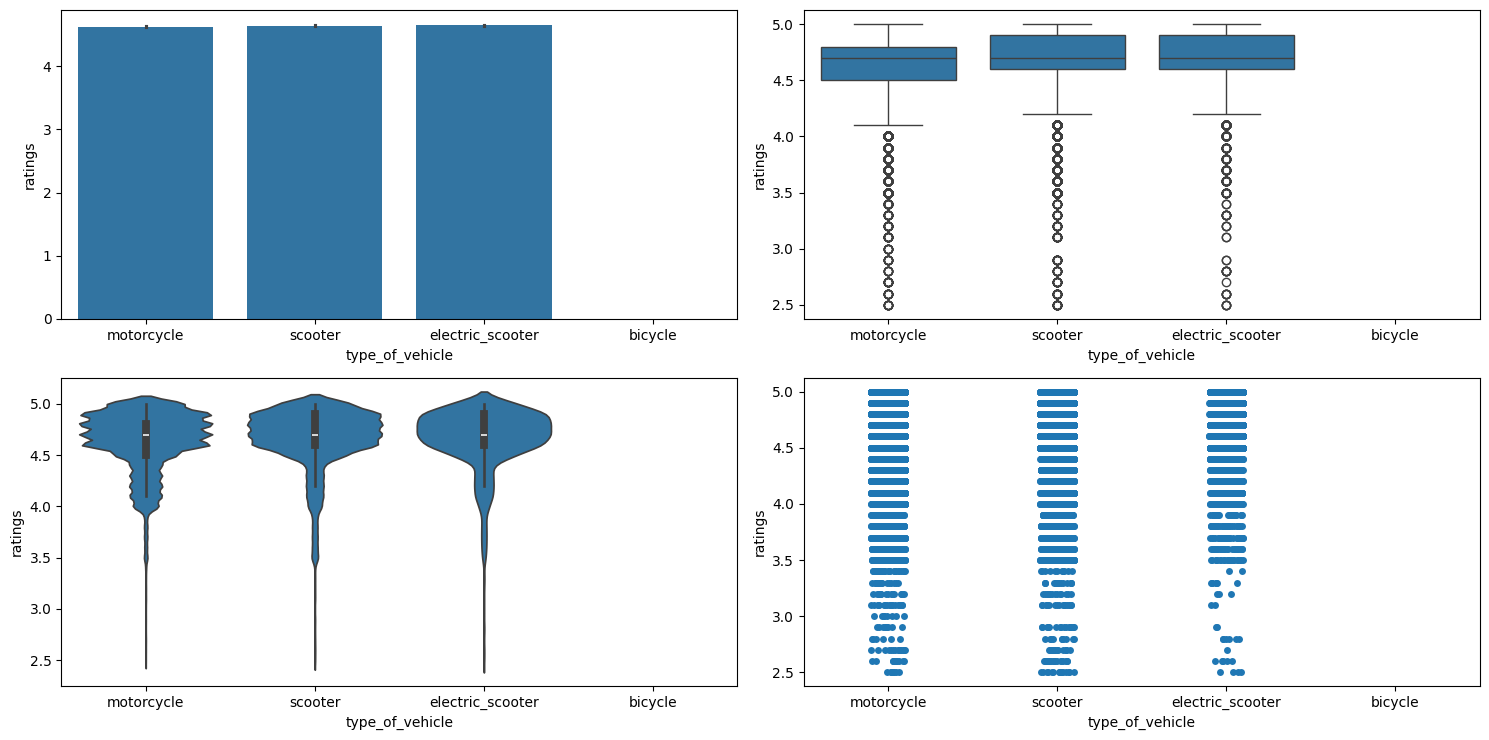

In [48]:
numerical_categorical_analysis(df, 'type_of_vehicle', 'ratings')

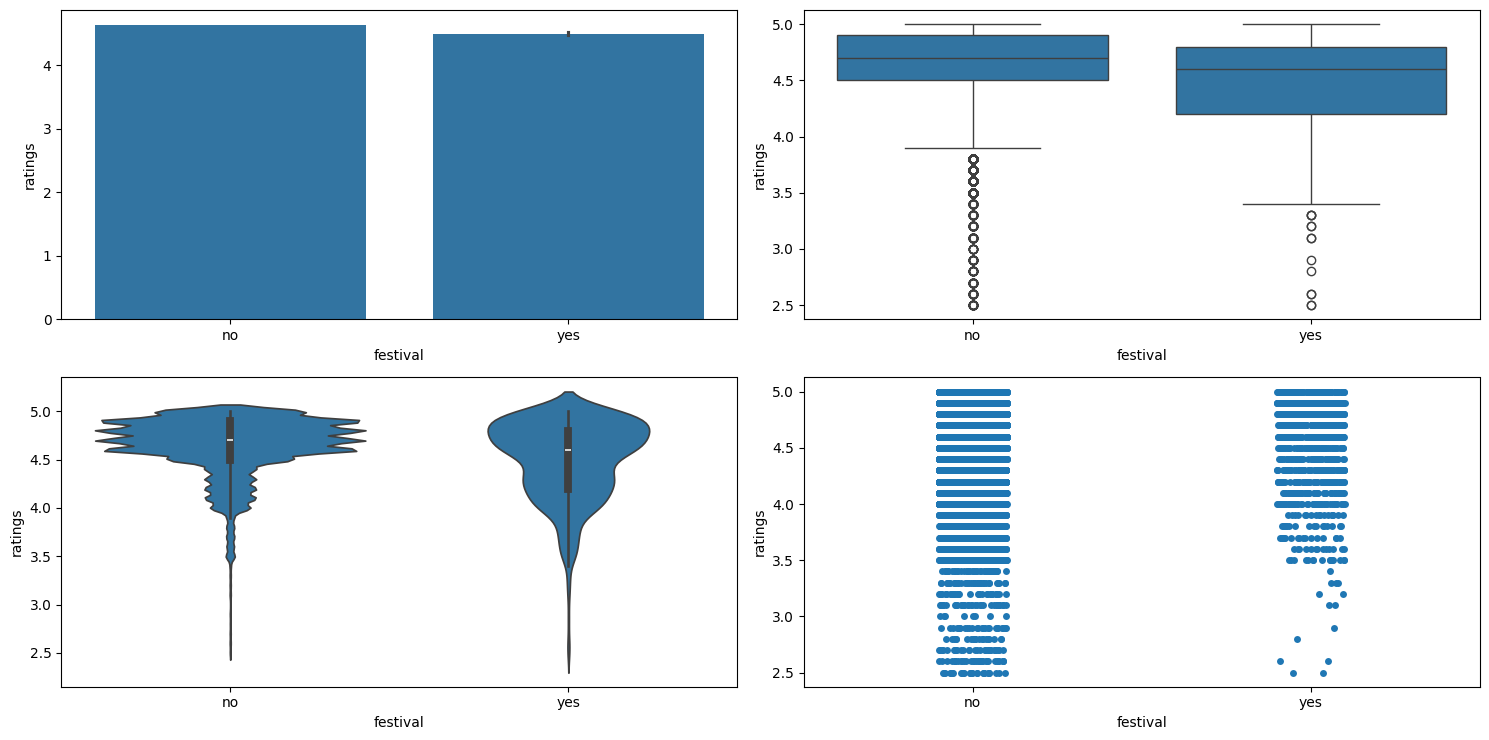

In [49]:
numerical_categorical_analysis(df, 'festival', 'ratings')

### Location Based Features

In [50]:
df.columns[3:7].tolist() + ["city_name"]

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [51]:
location_subset = df.loc[:,df.columns[3:7].tolist() + ["city_name"]]

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
56877,26.905190,75.810753,27.015190,75.920753,JAP
56878,26.902940,75.793007,26.912940,75.803007,JAP
56879,21.157735,72.768778,21.217735,72.828778,SUR
56880,22.320000,73.170000,22.450000,73.300000,VAD


In [52]:
location_subset.dtypes

restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
city_name                   str
dtype: object

In [53]:
location_subset.dropna(inplace=True)

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
56877,26.905190,75.810753,27.015190,75.920753,JAP
56878,26.902940,75.793007,26.912940,75.803007,JAP
56879,21.157735,72.768778,21.217735,72.828778,SUR
56880,22.320000,73.170000,22.450000,73.300000,VAD


In [55]:
delivery_df = pd.DataFrame({
    'latitude': location_subset['delivery_latitude'],
    'longitude': location_subset['delivery_longitude'],
    "city_name": location_subset["city_name"]
})


# Create a map using Plotly's scatter_map
fig = px.scatter_map(
    delivery_df,
    lat='latitude',
    lon='longitude',
    title="Delivery Points",
    hover_name="city_name"
)

# Update the layout for the map of India
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 20.5937, "lon": 78.9629},  # Centered over India
    mapbox_zoom=3,
)

# Show the plot
fig.show()

### Order Date

In [56]:
df.filter(like="order")

,order_date,type_of_order,order_day,order_month,order_day_of_week,order_time_hour,order_time_of_day
0,2022-03-19,snack,19,3,saturday,11.0,morning
1,2022-03-25,snack,25,3,friday,19.0,evening
2,2022-03-19,drinks,19,3,saturday,8.0,morning
3,2022-04-05,buffet,5,4,tuesday,18.0,evening
4,2022-03-26,snack,26,3,saturday,13.0,afternoon
...,...,...,...,...,...,...,...
56877,2022-03-27,snack,27,3,sunday,21.0,night
56878,2022-03-11,drinks,11,3,friday,11.0,morning
56879,2022-03-11,drinks,11,3,friday,NaN,after_midnight
56880,2022-03-06,meal,6,3,sunday,18.0,evening


In [57]:
order_date_subset = df.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]

order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,saturday,1,no
1,2022-03-25,25,3,friday,0,no
2,2022-03-19,19,3,saturday,1,no
3,2022-04-05,5,4,tuesday,0,no
4,2022-03-26,26,3,saturday,1,no
...,...,...,...,...,...,...
56877,2022-03-27,27,3,sunday,1,no
56878,2022-03-11,11,3,friday,0,no
56879,2022-03-11,11,3,friday,0,no
56880,2022-03-06,6,3,sunday,1,no


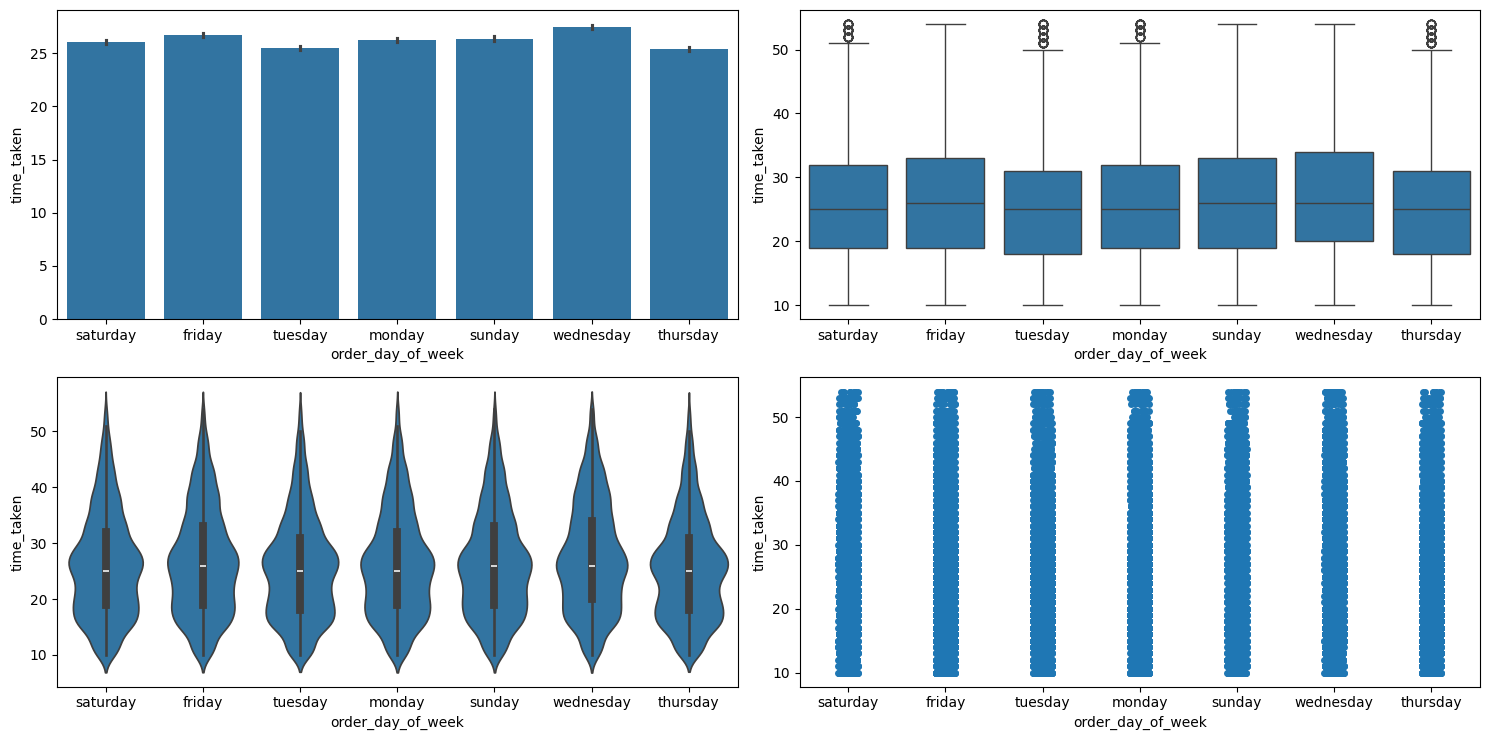

In [58]:
numerical_categorical_analysis(df, "order_day_of_week", "time_taken")

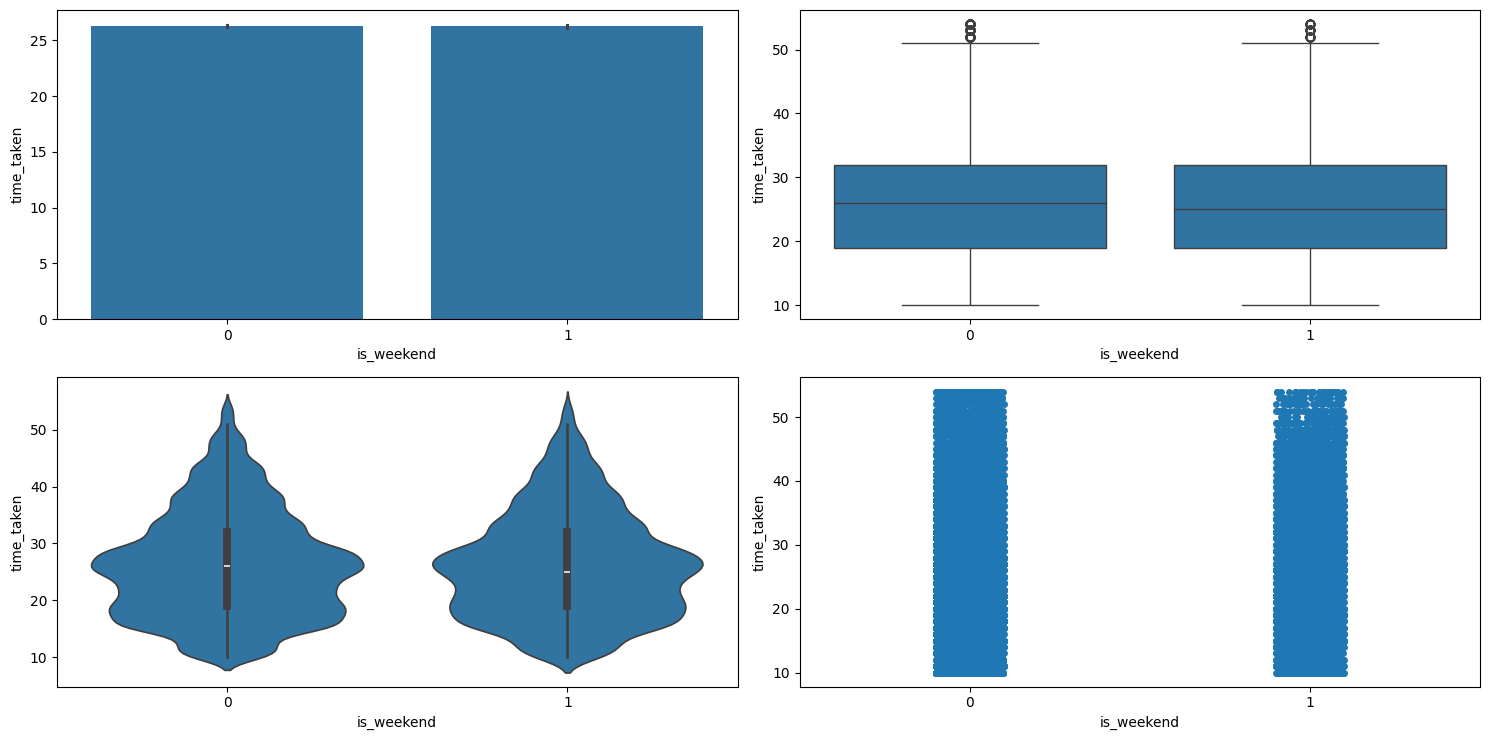

In [59]:
# does having a weekend affects target

numerical_categorical_analysis(df, "is_weekend", "time_taken")

In [60]:
# do weekends have an impact on traffic

chi_2_test(df, "is_weekend", "traffic")

0.4387455984908367
Fail to reject the null hypothesis. There is no significant association between is_weekend and traffic.


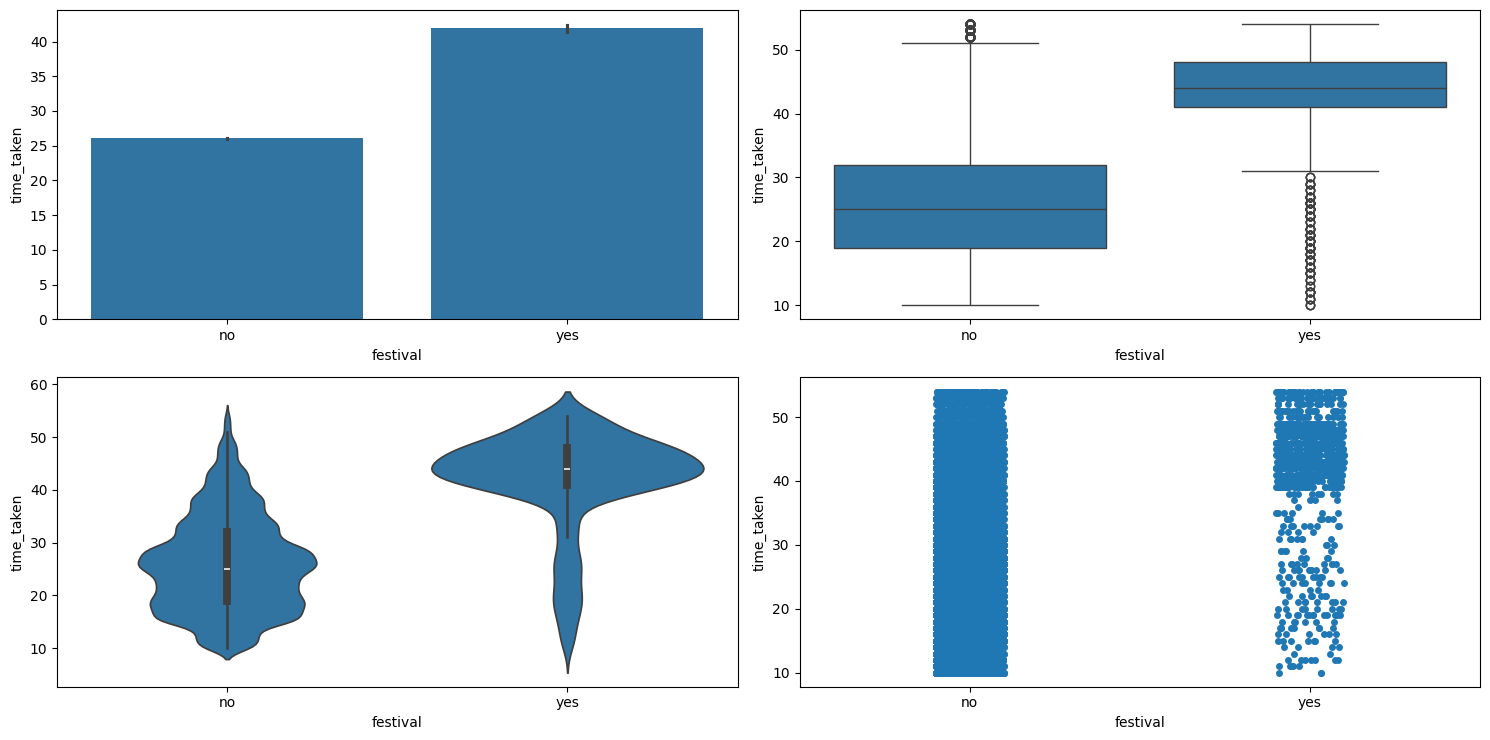

In [61]:
# festivals and target analysis

numerical_categorical_analysis(df, "festival", "time_taken")

Observations:

The avg time it takes for delivery varies when there is a festival.

The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer.

In [62]:
# do festival affect traffic

chi_2_test(df, "festival", "traffic")

8.416123727112304e-185
Reject the null hypothesis. There is a significant association between festival and traffic.


The p value is very small which mans it does affect traffic.

In [63]:
df.pivot_table(index="traffic",columns="festival",values="time_taken",aggfunc="mean")

festival,no,yes
traffic,,
high,26.861286,40.568421
jam,29.673181,42.520888
low,22.296571,39.833333
medium,26.496923,40.295597


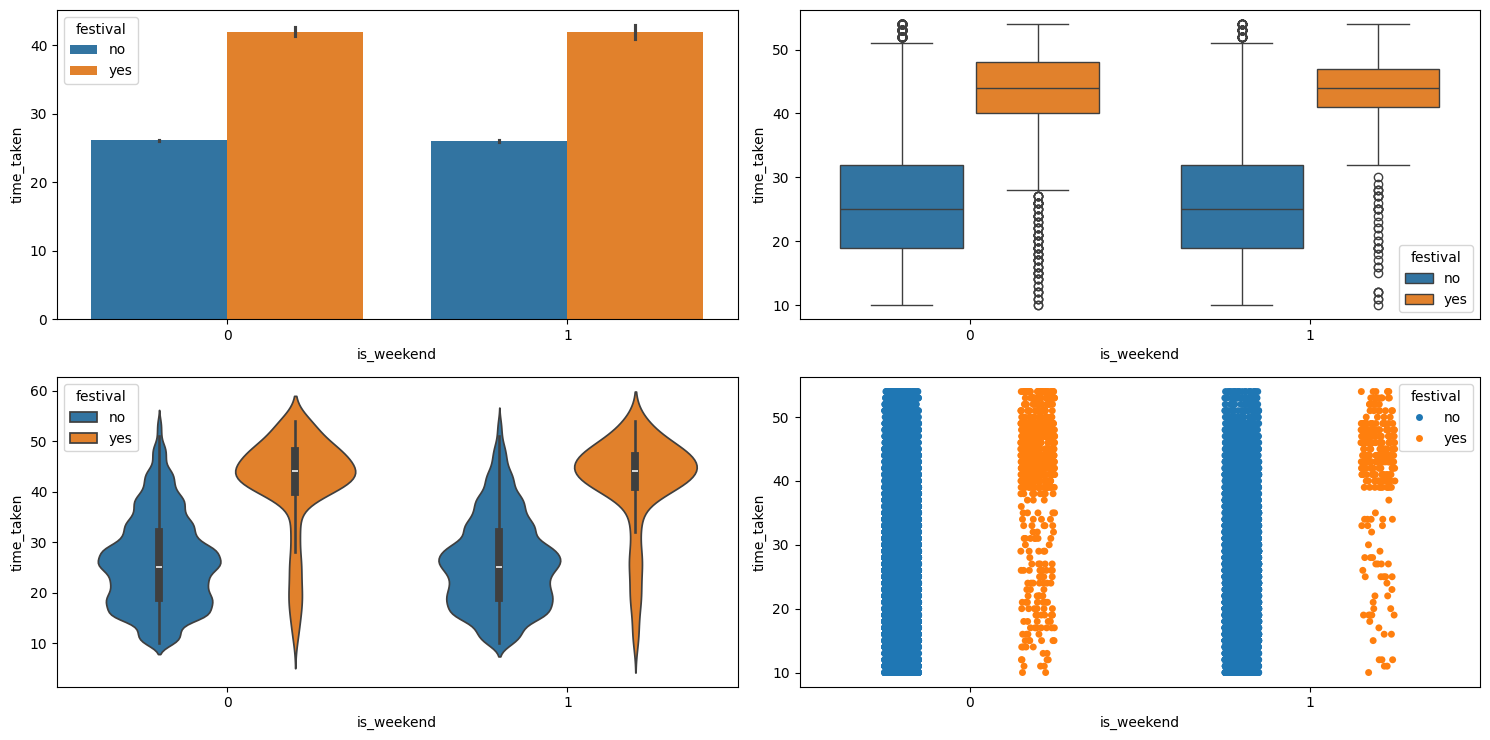

In [64]:
# does a weekend and a festival combined have an effect on delivery times

multivariate_analysis(df, "time_taken", "is_weekend", "festival")

### Order time

In [65]:
time_subset = df.loc[:,["order_time_hour","order_time_of_day","pickup_time_minutes"]]

time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
56877,21.0,night,10.0
56878,11.0,morning,5.0
56879,NaN,after_midnight,NaN
56880,18.0,evening,5.0


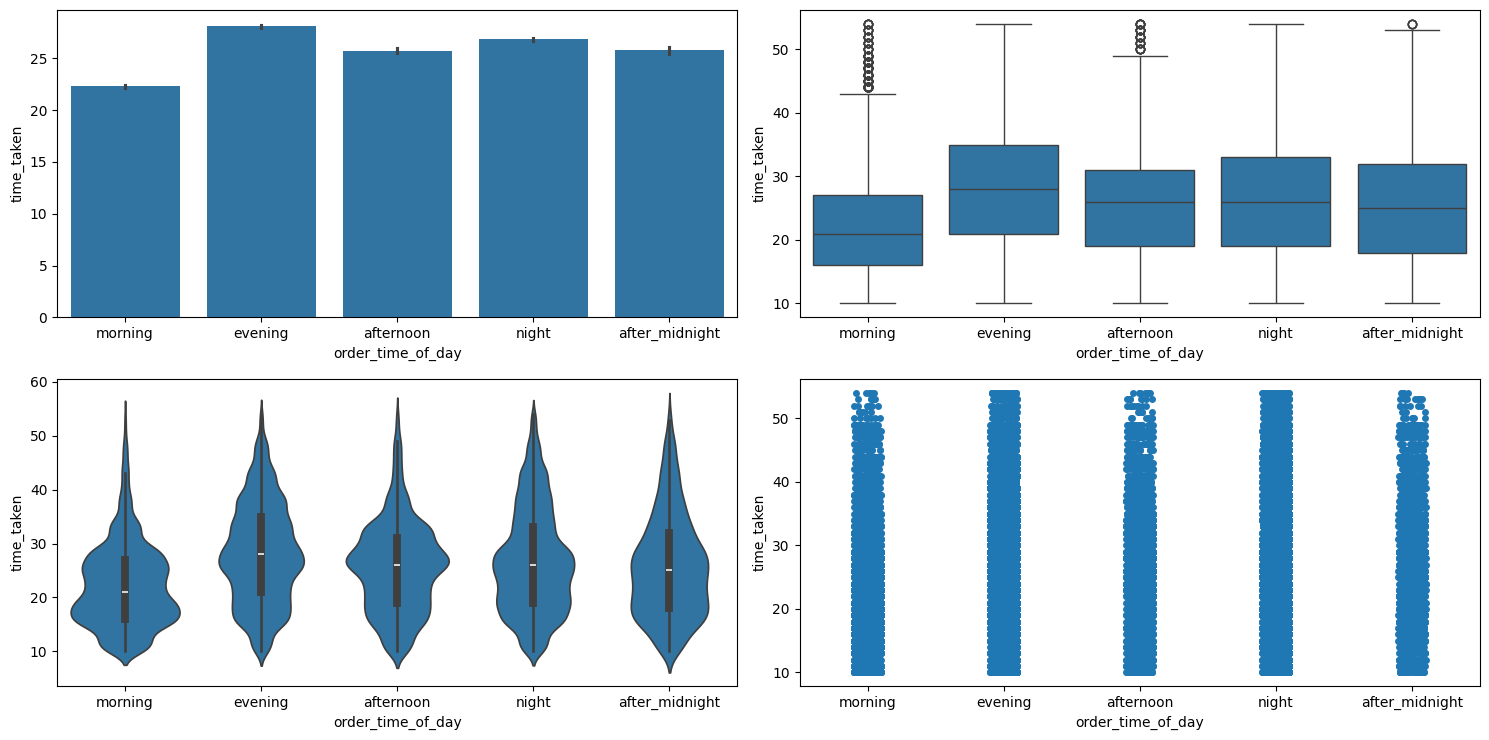

In [66]:
# does time of day affects delivery times

numerical_categorical_analysis(df, "order_time_of_day", "time_taken")

In [67]:
# relationship between time of day and traffic

chi_2_test(df, "order_time_of_day", "traffic")

0.0
Reject the null hypothesis. There is a significant association between order_time_of_day and traffic.


In [68]:
# anova test

anova_test(df, "time_taken", "order_time_of_day")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and order_time_of_day.


In [69]:
# Top 5 times(hrs) of the day in which customers  order the most

df["order_time_hour"].value_counts().head(5)

order_time_hour
21.0    5803
22.0    5731
19.0    5730
20.0    5709
23.0    5666
Name: count, dtype: int64

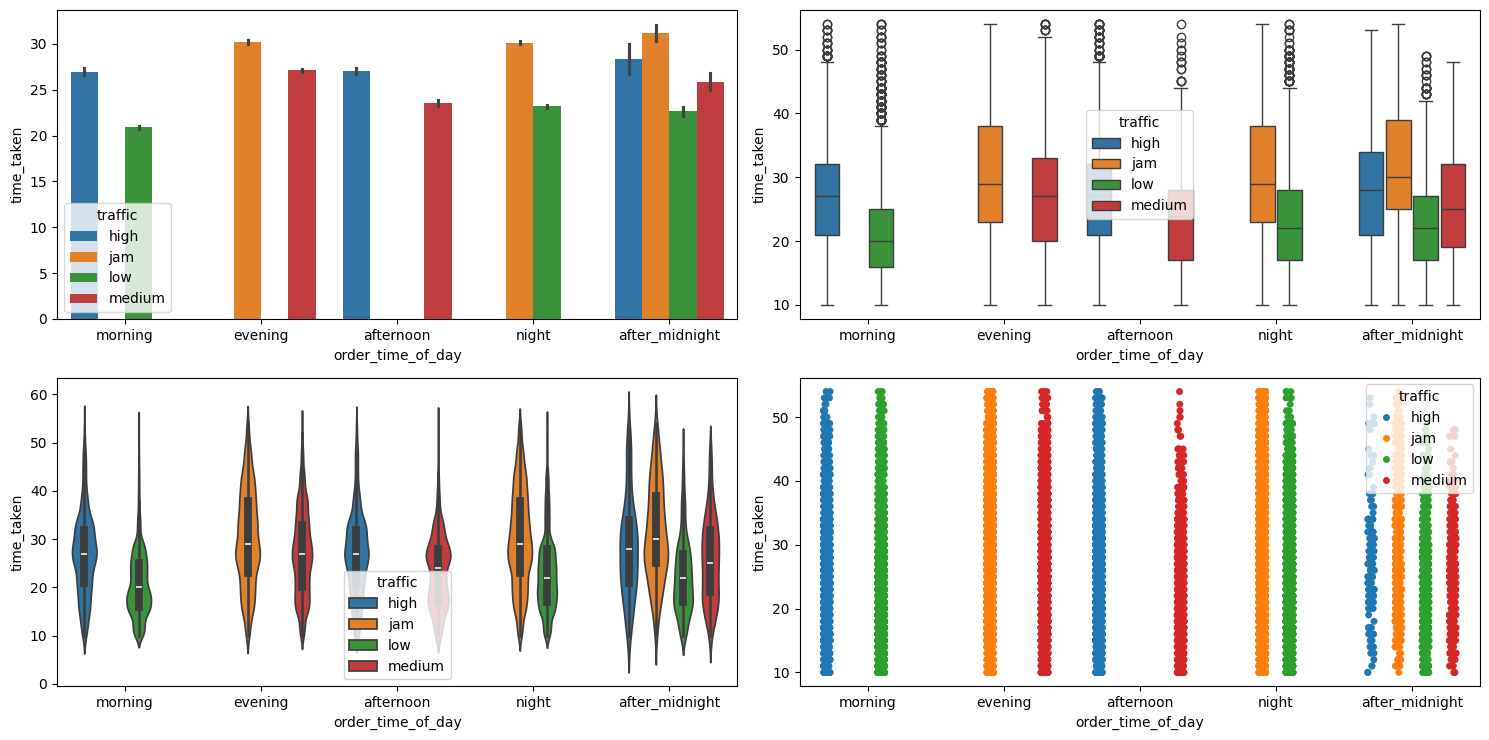

In [70]:
# can delivery time be affected by both time of day and traffic

multivariate_analysis(df, "time_taken", "order_time_of_day", "traffic")

,Count,Percentage
order_time_hour,,
21.0,5803,10.59%
22.0,5731,10.45%
19.0,5730,10.45%
20.0,5709,10.41%
23.0,5666,10.34%
18.0,5614,10.24%
17.0,5328,9.72%
11.0,2470,4.51%
10.0,2462,4.49%


**************************************************
The unique categories in order_time_hour column are [11.0, 19.0, 8.0, 18.0, 13.0, 21.0, 17.0, 20.0, 14.0, 9.0, 22.0, 12.0, 23.0, nan, 10.0, 16.0, 15.0, 0.0]
**************************************************
The number of categories in order_time_hour column are 17


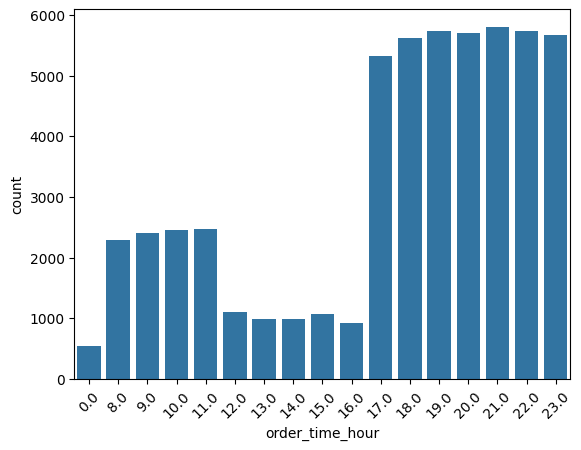

In [71]:
# categorical analysis on order_time_hour

categorical_analysis(df, "order_time_hour")

,Count,Percentage
order_time_of_day,,
night,22909,40.27%
evening,16672,29.31%
morning,9617,16.91%
afternoon,5071,8.91%
after_midnight,2613,4.59%


**************************************************
The unique categories in order_time_of_day column are ['morning', 'evening', 'afternoon', 'night', 'after_midnight']
**************************************************
The number of categories in order_time_of_day column are 5


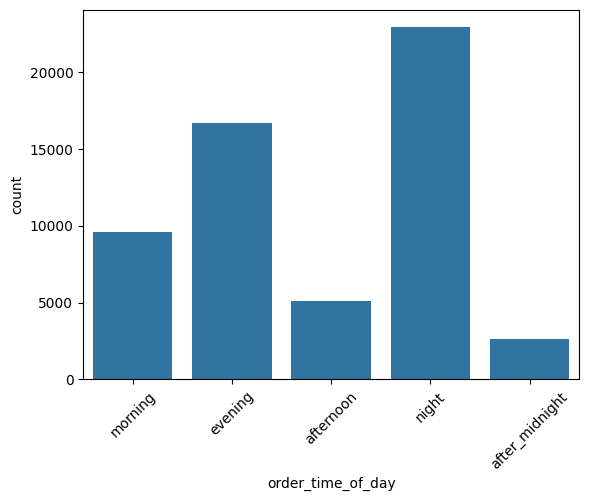

In [72]:
# categorical analysis on time of day

categorical_analysis(df, "order_time_of_day")